# 0. 문제 해결 파이프라인 (Y/N 이니까 분류)
   
* 미션 개요 (문제 정의 및 목표 설정)
* 기본 데이터 입력 및 EDA
* 전처리
* 드릴 다운 (할 수 있는게 있다면?)
* 모델링
* 결과 시각화 (Feature Importance)
* 결과 생성


# 🏦 스프린트 미션: 포르투갈 은행 마케팅 데이터 분석

## 1. 미션 개요

* **목표**: 은행 고객이 정기 예금을 가입할지 예측하는 분류 모델 만들기
* **방법**: 결정트리, 앙상블(RandomForest, XGBoost 등) 같은 분류 모델 활용
* **활용**: 예측 결과를 토대로 **마케팅 효율성**을 높이는 전략 제시

---

## 2. 데이터 정보

* **기간**: 2008년 \~ 2010년 (포르투갈 은행 마케팅 캠페인 데이터)
* **파일명**: `bank-additional-full.csv`
* **타깃(y)**: 고객이 정기 예금에 가입했는지 여부 (`yes` / `no`)

**주요 변수 예시**

## 3. 📂 데이터 변수 정리

| 변수명                | 타입  | 설명                                            |
| ------------------ | --- | --------------------------------------------- |
| **age**            | 숫자형 | 고객 나이                                         |
| **job**            | 범주형 | 직업 (예: admin, blue-collar, student 등)         |
| **marital**        | 범주형 | 결혼 여부 (married / single / divorced)           |
| **education**      | 범주형 | 교육 수준 (기초, 중등, 고등, 대학 등)                      |
| **default**        | 범주형 | 신용 불량 여부 (yes / no / unknown)                 |
| **housing**        | 범주형 | 주택 담보 대출 여부 (yes / no / unknown)              |
| **loan**           | 범주형 | 개인 대출 여부 (yes / no / unknown)                 |
| **contact**        | 범주형 | 연락 방식 (전화, 휴대폰 등)                             |
| **month**          | 범주형 | 마지막 캠페인 연락 월 (jan \~ dec)                     |
| **day\_of\_week**  | 범주형 | 마지막 연락 요일 (mon \~ fri)                        |
| **duration**       | 숫자형 | 마지막 통화 시간 (초 단위) → *주의: 예측 누수 위험*             |
| **campaign**       | 숫자형 | 이번 캠페인에서 고객에게 연락한 횟수                          |
| **pdays**          | 숫자형 | 이전 캠페인 후 경과 일수 (999 = 이전 캠페인 접촉 없음)           |
| **previous**       | 숫자형 | 이전 캠페인 동안 고객에게 연락한 횟수                         |
| **poutcome**       | 범주형 | 이전 캠페인 결과 (success / failure / nonexistent 등) |
| **emp.var.rate**   | 숫자형 | 고용률 변동 지표 (경제 지표)                             |
| **cons.price.idx** | 숫자형 | 소비자 물가지수 (CPI)                                |
| **cons.conf.idx**  | 숫자형 | 소비자 신뢰 지수                                     |
| **euribor3m**      | 숫자형 | 3개월 유리보 금리                                    |
| **nr.employed**    | 숫자형 | 고용자 수 (경제 전반 규모 반영)                           |
| **y**              | 타깃  | 정기 예금 가입 여부 (yes / no)                        |


* 개인 특성: 나이, 직업, 결혼 여부, 학력, 대출 여부 등
* 캠페인 특성: 연락 횟수, 이전 캠페인 반응, 연락 방식(전화, 이메일 등)
* 경제 지표: 금리(euribor3m), 고용률, 물가지수 등

---

## 4. 데이터 주의사항 (강사님 Tip)

1. `unknown` 값은 결측치처럼 처리
2. `pdays=999`는 “이전 캠페인에서 연락한 적 없음”을 의미
3. `duration`(통화 시간)은 정답(y)와 강하게 연결 → 실제 캠페인에선 **사용하지 않는 게 안전**

---

## 5. 우리가 고민해야 할 점

* **Precision(정밀도)**: 예측한 고객 중 실제로 가입한 비율
* **Recall(재현율)**: 실제 가입 고객 중 놓치지 않고 맞춘 비율

👉 어떤 걸 더 중요하게 볼지는 **비즈니스 상황**에 따라 다름

* **콜센터 리소스가 부족할 때**: Precision을 높이는 게 중요
  → 괜히 수만 명한테 연락해서 실제 가입은 몇 명 안 되면 손해가 큼
* **모든 잠재 고객을 놓치고 싶지 않을 때**: Recall을 높이는 게 중요 (전화했는데 가입안하면, 인건비 낭비가 굉장히 큼)
  → 인건비보다는 가입자를 많이 확보하는 게 목표일 때

---

## 6. 분석에서 해볼 질문들 (팀 디스커션 이후 정리)

* 직업, 학력에 따라 가입률 차이가 있나?
* 이전 캠페인 경험이 현재 가입에 영향을 주나?
* 특정 달(month)이나 요일(day\_of\_week)에 따라 반응률이 다른가?
* 경제 지표(금리, 고용률 등)가 가입에 영향을 주나?
* 가장 중요한 변수(Feature)는 무엇일까?

---

## 7. 분석 및 모델링 과정

1. **데이터 불러오기 → 전처리**

   * 결측치(`unknown`) 처리
   * `pdays=999`는 새로운 변수(`prev_contact`)로 변환
   * `duration`은 기본 모델에서는 제외

2. **EDA (탐색적 분석)**

   * 그룹별 가입률 비교 (예: 직업 vs 가입률)
   * 경제 지표와 가입률 관계 시각화

3. **모델링**

   * 로지스틱 회귀, KNN, 결정트리, 랜덤포레스트, XGBoost
   * 성능 비교 (PR-AUC, Precision, Recall, F1-score)

4. **결과 시각화**

   * Confusion Matrix
   * Precision-Recall Curve
   * Feature Importance

---

## 8. 최종 보고서 작성 팁

* **구조**:

  1. 문제 정의
  2. 데이터 설명 & 전처리 과정
  3. 탐색적 분석 결과 (그래프 포함)
  4. 모델별 성능 비교
  5. 최종 전략 제시 (Precision vs Recall 기준)
  6. 결론 및 제안

* **제출물**

  * Colab 노트북 (.ipynb)
  * 보고서 (.pdf)
  * 폴더 이름: `미션4_팀명_이름`


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

# 나눔바른고딕 경로 지정
path = '/Users/moon/Library/Fonts/NanumBarunGothic.ttf'

# 폰트 등록
fm.fontManager.addfont(path)
font_name = fm.FontProperties(fname=path, size=10).get_name()
plt.rc('font', family=font_name)   # matplotlib 기본 폰트로 지정

# 1-1. 기본 데이터 입력 및 EDA

In [ ]:
# 기본 명령어 치기

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head(50).T

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
age,56,57,37,40,56,45,59,41,24,25,...,58,32,38,57,44,42,57,40,35,45
job,housemaid,services,services,admin.,services,services,admin.,blue-collar,technician,services,...,management,entrepreneur,admin.,admin.,admin.,technician,admin.,blue-collar,admin.,blue-collar
marital,married,married,married,married,married,married,married,married,single,single,...,unknown,married,single,married,married,single,married,married,married,married
education,basic.4y,high.school,high.school,basic.6y,high.school,basic.9y,professional.course,unknown,professional.course,high.school,...,university.degree,high.school,professional.course,university.degree,university.degree,professional.course,university.degree,basic.9y,university.degree,basic.9y
default,no,unknown,no,no,no,unknown,no,unknown,no,no,...,no,no,no,no,unknown,unknown,no,no,no,no
housing,no,no,yes,no,no,no,no,no,yes,yes,...,yes,yes,no,no,yes,no,yes,no,yes,yes
loan,no,no,no,no,yes,no,no,no,no,no,...,no,no,no,yes,no,no,yes,yes,no,no
contact,telephone,telephone,telephone,telephone,telephone,telephone,telephone,telephone,telephone,telephone,...,telephone,telephone,telephone,telephone,telephone,telephone,telephone,telephone,telephone,telephone
month,may,may,may,may,may,may,may,may,may,may,...,may,may,may,may,may,may,may,may,may,may
day_of_week,mon,mon,mon,mon,mon,mon,mon,mon,mon,mon,...,mon,mon,mon,mon,mon,mon,mon,mon,mon,mon


In [ ]:
df.describe().T

df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

* 마케팅을 통해 가입하는 것에 대한 비율이 낮음.
* 학습할 데이터가 불균형

## 0) y - 종속변수 이진변환

✅ 종속변수를 이진변환하는 이유

    - 문제 단순화: “가입(yes) vs 비가입(no)”처럼 두 가지 결과만 예측하면 모델이 단순해지고 해석이 쉬움.
    - 모델 적용성: 로지스틱 회귀, 이진 분류기 같은 알고리즘은 target이 0/1 형식일 때 가장 잘 작동.
    - 성능 비교 용이: 정확도, 정밀도, 재현율 같은 지표가 명확하게 계산됨.

In [ ]:
df['y'] = df['y'].map(
    {
    'yes': 1,
    'no': 0
}
)

In [ ]:
print(df['y'].unique())

[0 1]


## 1) qcut (강사님이 말씀해주신 방법)

#### 📌 pd.cut vs pd.qcut 차이

- **pd.cut**
  - 값의 **범위(구간 길이)**를 기준으로 일정 간격으로 나눔  
  - 예: 나이 0~100 → (0,25], (25,50], (50,75], (75,100]  
ㅡ
- **pd.qcut**
  - 값의 **분위수(quantile)**를 기준으로 데이터 개수가 비슷하게 나눔  
  - 예: 데이터 100개를 4등분 → 각 구간에 25개씩 들어가도록 분할  

✅ 정리:  
- `pd.cut` → **간격 동일**  
- `pd.qcut` → **데이터 개수 동일**

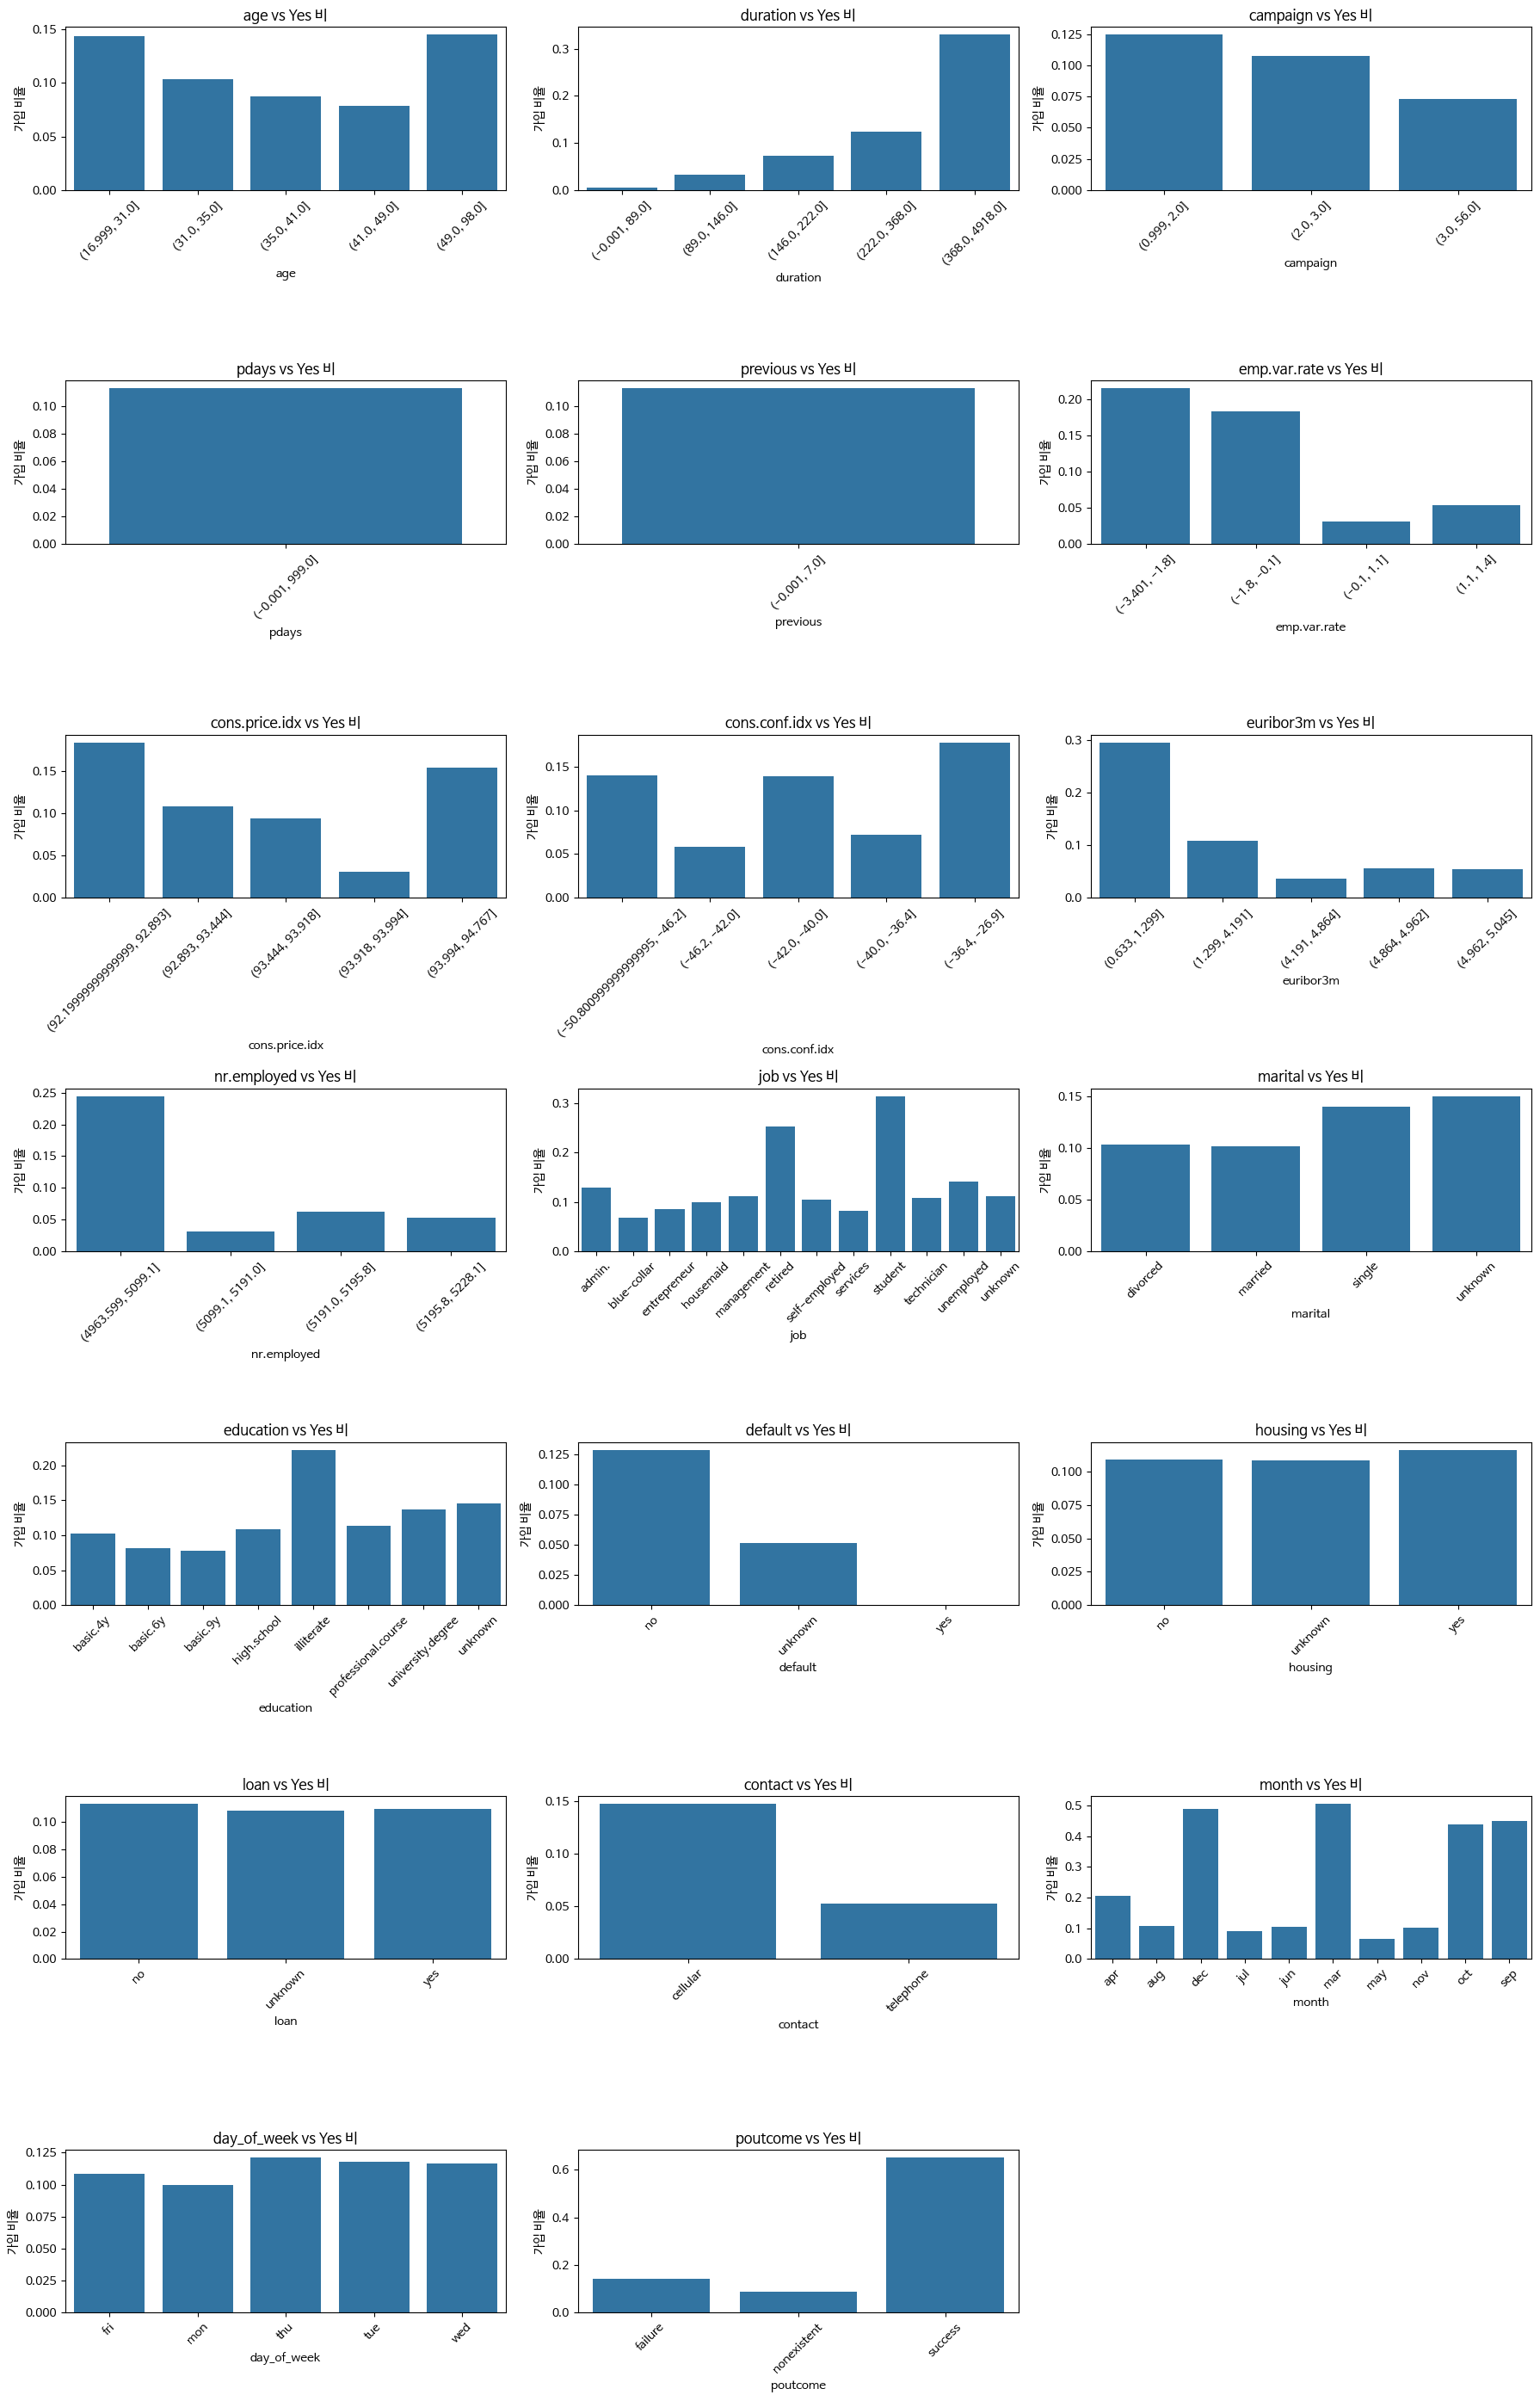

In [ ]:
# 수치형, 범주형 구분
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['y']).columns   # 숫자형 변수들만 추출(y 제외)
cat_cols = df.select_dtypes(exclude=[np.number]).columns                       # 숫자가 아닌 변수들(범주형) 추출

# 수치형 변수 5구간으로 나누기
df_binned = df.copy()                                                          # 원본 데이터 복사
for col in num_cols:                                                           # 수치형 변수 각각에 대해
    df_binned[col] = pd.qcut(df_binned[col], q=5, duplicates='drop')           # 분위수 기준 5구간으로 분할 (중복 구간 제거)

# 시각화
ncols = 3   # subplot 한 행에 3개씩 배치
nrows = int(np.ceil((len(num_cols) + len(cat_cols)) / ncols))  # 전체 변수를 3개씩 끊어서 필요한 행 수 계산 (올림 처리)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4*nrows))  # subplot 생성 (크기: 가로 18, 세로 4*nrows)
axes = axes.flatten()  # axes를 1차원 리스트로 변환 → for문에서 쓰기 쉽게

all_cols = list(num_cols) + list(cat_cols)  # 수치형 + 범주형 컬럼 합치기

for i, col in enumerate(all_cols):
    ax = axes[i]  # 현재 subplot 선택
    tmp = df_binned.groupby(col)['y'].mean().reset_index()  # 해당 변수별 가입 여부 평균값 계산 (가입 비율)
    sns.barplot(x=col, y='y', data=tmp, ax=ax)  # 막대그래프: 변수값 vs 가입 비율
    ax.set_title(f"{col} vs Yes 비")  # 그래프 제목
    ax.set_ylabel("가입 비율")  # y축 레이블
    ax.set_xlabel(col)  # x축 레이블
    ax.tick_params(axis='x', rotation=45)  # x축 눈금을 45도 회전 (글자 겹침 방지)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)  # 남는 subplot이 있으면 숨김 처리

plt.tight_layout()  # subplot 간격 자동 조정
plt.show()  # 최종 그래프 출력

# 1-2. EDA

## 1) 간단개요

### 👤 고객 특성

`나이 (age)`

* 평균 40세, 중앙값 38세 → 30\~50대 중심
* 분포: 비교적 **대칭**, 고령(98세) 극단값 존재
* 의미: 중년층 고객이 주 타겟, 일부 노년층도 포함

`통화시간 (duration)`

* 평균 4분, 중앙값 3분 → 대부분 짧은 통화
* 분포: **Right-skewed (오른쪽 꼬리)** → 일부 매우 긴 통화 존재
* 의미: 짧은 통화가 일반적이나, 성공적일 때는 긴 통화로 이어질 가능성

`캠페인 연락 횟수 (campaign)`

* 평균 2.5회, 중앙값 2회 → 대부분 1\~3회
* 분포: **Right-skewed** (극단값 56회)
* 의미: 대다수는 1\~3회 시도 내에 결과가 갈림

---

### 📞 과거 캠페인

`pdays`

* 대부분 999 (연락 없음 의미)
* 분포: **한 값(999)에 집중**
* 의미: 신규 고객 중심의 캠페인

`previous`

* 평균 0.17회, 대부분 0회
* 분포: **Right-skewed** (소수만 경험 多)
* 의미: 과거 성공 캠페인 경험 거의 없음

---

### 📈 경제 지표

`고용 변동률 (emp.var.rate)`

* 뜻: 분기별 고용율의 변화율. 경제가 성장하면 고용이 늘어나고, 불황이면 줄어듦.
* 값이 -3.4일 때는 경기 침체, +1.4일 때는 경기 호황을 반영.
* -3.4 \~ 1.4 → 경기 상황 따라 크게 변동
* 분포: **다봉형 (multi-modal)**
* 의미: 불황기(-)일 때 마케팅 반응률에 영향 가능

`소비자 물가 (cons.price.idx)`

* 뜻: 인플레이션을 나타내는 지표. 기준 시점 대비 물가 수준을 수치화.
* 92.2 \~ 94.8 → 안정적
* 분포: **정규분포형에 가까움**
* 의미: 물가 자체보다는 추세 변화가 중요

`소비자 신뢰 (cons.conf.idx)`

* 뜻: 소비자들이 경제 상황(소득, 고용, 경기)에 대해 얼마나 낙관/비관적으로 느끼는지 나타냄. (보통 -50~+50 범위)
* 평균 -40, 범위 -50 \~ -27
* 분포: **전반적으로 낮음**
* 의미: 비관적 소비 심리가 지배적 → 금융상품 가입에 부정적

`유리보 금리 (euribor3m)`

* 뜻: 유럽 은행들이 3개월 만기 자금을 서로 빌려줄 때 적용하는 금리(Europe Interbank Offered Rate).
* → 저금리 땐 대출 유리, 고금리 땐 예금 유리 → 고객 반응이 금리 상황에 따라 달라짐.
* 0.63% \~ 5% → 큰 편차
* 분포: **Right-skewed**
* 의미: 금리 수준에 따라 대출/예금 선택 크게 달라질 수 있음

`고용 인원 (nr.employed)`

* 뜻: 경제 내 취업자 수. 거시경제에서 노동시장의 상태를 보여주는 지표.
* 약 4964 \~ 5228명
* 분포: **좁은 범위 내 안정적**
* 의미: 노동시장 상황 반영, 거시적 경기 지표

## 2) 심층 분석

### A. pdays

<Axes: xlabel='pdays', ylabel='Count'>

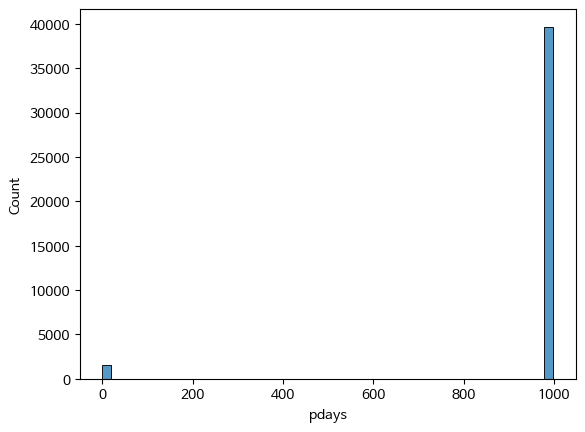

In [ ]:
## 종속변수 y 의 이진화 ㄱㄱ

sns.histplot(df["pdays"], bins=50)

In [ ]:
np.sort(df['pdays'].unique())

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  25,  26,  27,
       999])

- 이전에 연락 받은 친구 혹은 받지 않은 사람으로 나누어봐도 괜찮을 듯.

###  B. previous

In [ ]:
df['previous'].value_counts(normalize=True)

previous
0    0.863431
1    0.110736
2    0.018306
3    0.005244
4    0.001700
5    0.000437
6    0.000121
7    0.000024
Name: proportion, dtype: float64

<Axes: xlabel='previous', ylabel='Count'>

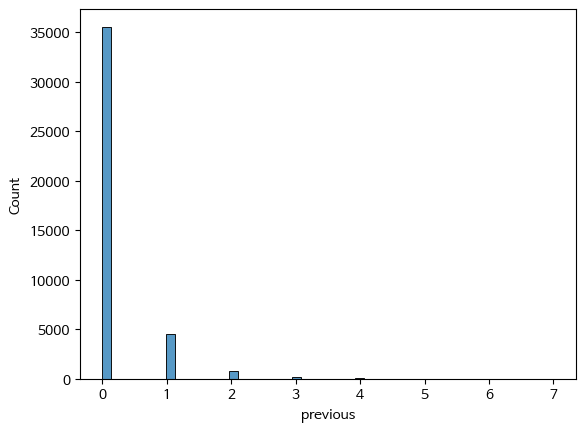

In [ ]:
sns.histplot(df["previous"], bins=50)

* 연락 유/무에 대한 파생변수도 다룰 필요 있음. (86% 연락 받은 적 없음)

### C. Unknown

In [ ]:
target_cols = ['default','education', 'housing', 'loan', 'job', 'marital']

unknown_summary = {}

for col in target_cols:
    unknown_count = (df[col] == 'unknown').sum()

    if unknown_count > 0:
        unknown_summary[col] = {
            'count': unknown_count,
            'ratio': round(unknown_count / len(df) * 100, 2)
        }

# DataFrame으로 변환 + 보기 좋게 정렬
unknown_df = pd.DataFrame(unknown_summary).T
unknown_df = unknown_df.sort_values(by='ratio', ascending=False)

unknown_df

,count,ratio
default,8597.0,20.87
education,1731.0,4.20
housing,990.0,2.40
loan,990.0,2.40
job,330.0,0.80
marital,80.0,0.19


- default : 신용 불량 여부 (yes / no / unknown)
- education :교육 수준 (기초, 중등, 고등, 대학 등)
- Housing: 주택 담보 대출 여부 (yes / no / unknown)
- Loan:	개인 대출 여부 (yes / no / unknown)
- job : 결혼 여부 (married / single / divorced)
- martial : 결혼 여부 (married / single / divorced)

### D. poutcome (이전 캠페인 결과)

<Axes: xlabel='poutcome', ylabel='Count'>

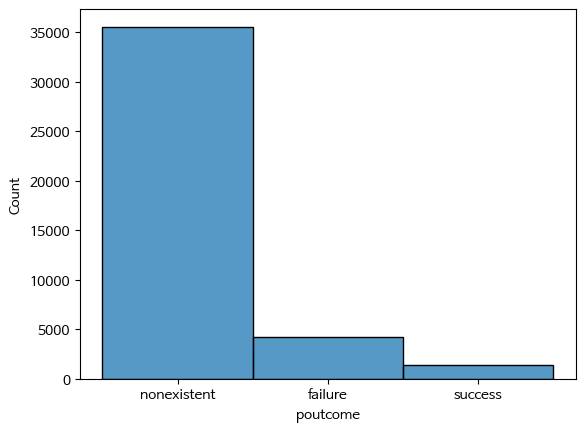

In [ ]:
sns.histplot(df["poutcome"], bins=50)

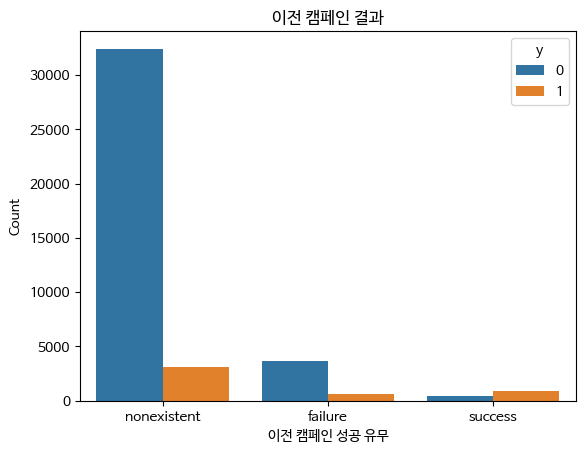

In [ ]:
sns.countplot(
    data=df,
    x='poutcome',   # 이전 캠페인 결과
    hue='y'         # 현재 캠페인 성공 여부 (이거에 대한 결과 나누기) -> 꼭 기억할 것.
)

plt.title('이전 캠페인 결과')
plt.xlabel('이전 캠페인 성공 유무')
plt.ylabel('Count')

plt.show()

In [ ]:
df.groupby(by='poutcome')['y'].value_counts(normalize=True)

poutcome     y
failure      0    0.857714
             1    0.142286
nonexistent  0    0.911678
             1    0.088322
success      1    0.651129
             0    0.348871
Name: proportion, dtype: float64

- 지난 번에 참여한 사람들 중에 이번에도 참여한 사람이 많음.

# 2. 전처리

## (1) 중복값

In [ ]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,0
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,0
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,0
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0


In [ ]:
df.value_counts().reset_index(name='count').query("count >= 3")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,count


- 두개 이상 12개.
- 세개 이상 겹치는 중복값이 없음. 다른 사람이라도 답이 두개 이상 겹칠 수 있으니 이는 중복치라고 판단하지 않음.

## (2) 결측치

In [ ]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

- 결측치는 없음

## (3) 이상치

In [ ]:
# 1-1에서 확인한 이상치 모두 확인

#duration - 이상치라 판단 근거 없음
#campaign
#previous - 이상치라 판단 근거 없음
#euribor3m - 이상치라 판단 근거 없음
#pdays - 이상치라 판단 근거 없음

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

#### (a) Campaign

In [ ]:
df["campaign"].describe()

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

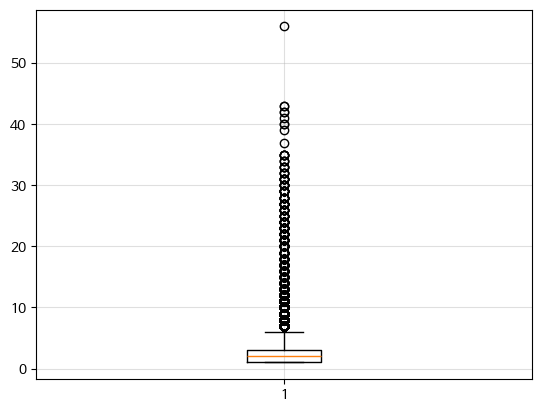

In [ ]:
# campaign - 이상치 확인 (데이터 확인 파트와 동일) - 이번 캠페인에서 고객에게 연락한 횟수

plt.boxplot(df['campaign'])                        # 'campaign' 컬럼으로 박스플롯 생성
plt.grid(True, alpha=0.4)                          # 그리드 표시 (투명도 0.4)
plt.show()                                         # 그래프 출력

- Z-score 3이상이면,이상치로 간주

In [ ]:
mean = df["campaign"].mean()
std = df["campaign"].std()

print(f"({mean:.2f}, {std:.2f})")


(2.57, 2.77)


In [ ]:
upper = mean + 3 * std
print(f"Z=+3 이상 cutoff: {upper:.2f}")

Z=+3 이상 cutoff: 10.88


In [ ]:
outliers=(df["campaign"] >= 10.88).sum()
print(f"{outliers/41188.00000*100}")

2.1098378168398564


- 2%는 이상치로 간주하고 삭제해도 괜찮다고 판단.

In [ ]:
df=df[df["campaign"] <= 10.88]
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000,40319.000000
mean,40.014435,260.494134,2.273816,961.737221,0.176418,0.058851,93.567936,-40.503133,3.597617,5166.031288,0.114413
std,10.436785,259.386503,1.718083,188.718269,0.499271,1.575692,0.579282,4.652669,1.740848,72.524768,0.318316
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,104.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000,0.000000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,321.500000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,10.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


### (b) Duration

✅ 예측 누수(leakage) 간단 설명

- 정의: 예측 시점에는 알 수 없는 정보를 학습에 사용해 성능이 비현실적으로 높아지는 현상
- duration 문제: 마지막 통화 시간은 결과(y)와 직접적으로 연결 → 전화를 걸기 전엔 알 수 없음
- 결론: 모델 학습엔 제외해야 하고, 분석용 변수로만 활용 가능
    - 👉🏼 수업시간 삭제하기로 결론!

In [ ]:
df.drop(columns=['duration'], inplace=True)
# inplace=True = 원본을 직접 바꾸기
# inplace=False = 원본은 그대로 두고 새로운 걸 반환하기

## (4) 파생 변수 추가

### (a) pdays

In [ ]:
# pdays - 이전에 연락을 받은 적 있는지?
df['prev_contact'] = (df['pdays'] != 999).astype(int)

# .astype(int) - True → 1
# .astype(int) - False → 0

### (b) 범주형 데이터

| 변수명 (Variable) | 건수 (count) | 비율 (ratio, %) | 주요 범주 (Categories) |
|------------------|-------------:|----------------:|------------------------|
| default          | 8,597        | 20.87 | yes / no / unknown |
| education        | 1,731        | 4.20  | primary / secondary / tertiary / illiterate / unknown |
| housing          | 990          | 2.40  | yes / no / unknown |
| loan             | 990          | 2.40  | yes / no / unknown |
| job              | 330          | 0.80  | admin. / blue-collar / entrepreneur / housemaid / management / retired / self-employed / services / student / technician / unemployed / unknown |
| marital          | 80           | 0.19  | married / single / divorced / unknown |

#### 1. 모델 학습의 안정성 확보
- 범주형 데이터를 라벨 인코딩할 때, `unknown` 같은 값이 정상 범주(label)와 섞이면 모델이 이를 일반 값처럼 학습해버림.  
- 예: `job` 컬럼에 `admin.`, `technician`, `blue-collar` 같은 실제 직업이 있는데, 여기에 `unknown`이 포함되면 모델은 `"unknown도 직업이구나"` 하고 잘못 이해할 수 있음.  
- 따라서 `unknown`은 정상 범주에서 **제외**하고, 나머지만 학습하도록 처리해야 함.  

#### 2. 새로운 데이터 대응 (Generalization)
- 추후 예측 시, 학습 단계에서 보지 못한 새로운 값(예: 새로운 직업명)이 들어올 수 있음.  
- 이 경우에도 결국 "모르는 값"은 `unknown`으로 분류해야 함.  
- 이를 위해 `unknown`을 별도의 레이블(**= 최대 라벨 값 + 1**)로 지정해 두면, 모델이  
  - 0, 1, 2 → 정상 범주  
  - 마지막 값 → 모르는 값(`unknown`)  
  으로 구분할 수 있어 안정적.  

---

#### ✅ 정리
- 라벨 인코딩 시 `unknown`을 일반 값과 섞지 않고 따로 관리하기 위함  
- 예측 단계에서 새로운 값이 들어와도 안정적으로 대응하기 위함  

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ✅ unknown을 따로 처리하는 라벨 인코딩 함수
def custom_label_encode(df, column):
    """
    범주형 변수(column)를 라벨 인코딩하되,
    - 'unknown'은 일반 값에서 제외
    - 'unknown'은 마지막 라벨 번호(max+1)로 지정
    """

    # 1. 정상 값만 따로 추출 (unknown 제외)
    valid_values = df.loc[df[column] != 'unknown', column]

    # 2. LabelEncoder로 정상 값 학습
    le = LabelEncoder()
    le.fit(valid_values)

    # 3. unknown에 줄 번호 = 최대 라벨값 + 0 (len(le.classes_))
    unknown_label = len(le.classes_)

    # 4. 실제 인코딩: unknown이면 unknown_label, 아니면 LabelEncoder 값
    def encode_value(x):
        if x == 'unknown':
            return unknown_label
        else:
            return le.transform([x])[0]

    encoded_col = df[column].apply(encode_value)

    return encoded_col


# ✅ 범주형 변수 목록 가져오기
categorical_cols = df.select_dtypes(include='object').columns

# ✅ 모든 범주형 변수에 대해 변환 적용
for col in categorical_cols:
    df[col + '_encoded'] = custom_label_encode(df, col)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'prev_contact', 'job_encoded',
       'marital_encoded', 'education_encoded', 'default_encoded',
       'housing_encoded', 'loan_encoded', 'contact_encoded', 'month_encoded',
       'day_of_week_encoded', 'poutcome_encoded'],
      dtype='object')

In [ ]:
# 나이 관련
# 30~45세 또는 60세 이상이면 1, 아니면 0
df["is_target_age"] = ((df["age"].between(30, 45)) | (df["age"] >= 60)).astype(int)

# 직업 관련
# 직업이 student 또는 retired면 1, 아니면 0
df["is_student_or_retired"] = df["job"].isin(["student", "retired"]).astype(int)

# 학력 관련
# 교육 수준이 대학교 학위(university.degree) 이상 또는 전문 과정이면 1, 아니면 0
df["is_high_edu"] = df["education"].isin(["university.degree", "professional.course"]).astype(int)

# 이전 캠페인 성공 경험
# poutcome이 success면 1, 아니면 0
df["had_prev_success"] = (df["poutcome"] == "success").astype(int)

# 연락 방식이 휴대폰인지 여부
# contact가 cellular면 1, 아니면 0
df["is_cellular"] = (df["contact"] == "cellular").astype(int)

# 성과가 높았던 월인지
# month가 5월, 8월, 10월, 12월이면 1, 아니면 0
df["is_target_month"] = df["month"].isin(["may", "aug", "oct", "dec"]).astype(int)


# 경제 지표 관련
# euribor3m 값이 중앙값보다 낮으면 1, 아니면 0
df["low_euribor3m"] = (df["euribor3m"] < df["euribor3m"].median()).astype(int)

# 고용 변동률(emp.var.rate)이 음수면 1, 아니면 0
df["neg_emp_var_rate"] = (df["emp.var.rate"] < 0).astype(int)

# 소비자 신뢰 지수(cons.conf.idx)가 중앙값보다 낮으면 1, 아니면 0
df["low_cons_conf"] = (df["cons.conf.idx"] < df["cons.conf.idx"].median()).astype(int)


# 연락 횟수 관련
# campaign 횟수가 2 이하이면 1, 아니면 0
df["few_contacts"] = (df["campaign"] <= 2).astype(int)


# 3. 드릴 다운 (할 수 있는게 있다면? qcut & 히트맵)

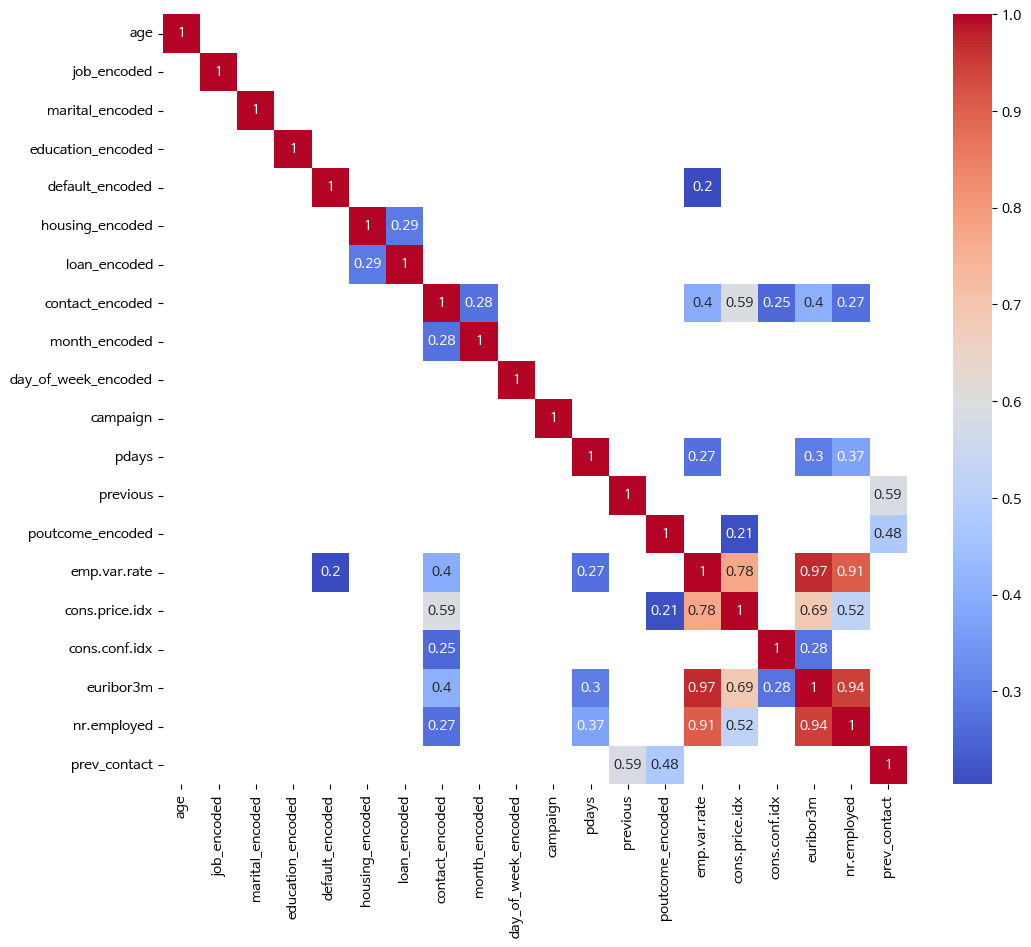

In [ ]:
feature_0 =['age', 'job_encoded', 'marital_encoded', 'education_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded',
       'contact_encoded', 'month_encoded', 'day_of_week_encoded', 'campaign', 'pdays', 'previous',
       'poutcome_encoded', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'prev_contact']

df_selected = df[feature_0]
# 숫자형 데이터만 추출
numeric_df = df_selected.select_dtypes(include='number')

# 상관계수 계산
corr = numeric_df.corr()

corr_up = corr[corr>0.2]
# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_up, annot=True, cmap='coolwarm')
plt.show()

# 4. 모델링

## 1) 1차 모델링

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'prev_contact', 'job_encoded',
       'marital_encoded', 'education_encoded', 'default_encoded',
       'housing_encoded', 'loan_encoded', 'contact_encoded', 'month_encoded',
       'day_of_week_encoded', 'poutcome_encoded', 'is_target_age',
       'is_student_or_retired', 'is_high_edu', 'had_prev_success',
       'is_cellular', 'is_target_month', 'low_euribor3m', 'neg_emp_var_rate',
       'low_cons_conf', 'few_contacts'],
      dtype='object')

In [ ]:
print(df['y'].unique())

[0 1]


In [ ]:
from sklearn.model_selection import train_test_split

feature_1 =['age', 'job_encoded', 'marital_encoded', 'education_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded',
       'contact_encoded', 'month_encoded', 'day_of_week_encoded', 'campaign', 'pdays', 'previous',
       'poutcome_encoded', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'prev_contact']

In [ ]:
X=df[feature_1]
y=df['y']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'Voting': VotingClassifier(estimators=[
        ('dt', DecisionTreeClassifier()),
        ('rf', RandomForestClassifier()),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
    ]),
    'Stacking': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier()),
            ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
        ],
        final_estimator=LogisticRegression()
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_1 = []

for name, model in models.items():
    model.fit(X_train, y_train)                 # 1. 모델 학습
    preds = model.predict(X_test)               # 2. 테스트 데이터 예측

    # 3. 평가 지표 계산
    acc = accuracy_score(y_test, preds)         # 정확도
    prec = precision_score(y_test, preds)       # 정밀도
    rec = recall_score(y_test, preds)           # 재현율
    f1 = f1_score(y_test, preds)                # F1 점수

    # 4. 결과 저장 (딕셔너리 형태로 저장 후 리스트에 append)
    results_1.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

In [ ]:
results_1 = pd.DataFrame(results_1)
results_1

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.832259,0.313823,0.352201,0.331906
1,Random Forest,0.891700,0.577267,0.315863,0.408311
2,Bagging,0.883763,0.515528,0.290007,0.371199
3,AdaBoost,0.896081,0.719697,0.199161,0.311987
4,XGBoost,0.893436,0.601140,0.294899,0.395687
5,Voting,0.890377,0.568627,0.303983,0.396175
6,Stacking,0.894759,0.638596,0.254368,0.363818


* Recall의 점수가 너무 낮음
* 잠재 고객을 놓칠 수 있음

In [ ]:
# 코딩시 이걸 보는 것도 좋음 (강사님 추천) -> 꼭 같이 봐라. 왜냐하면, 평균값은 모든 걸 보여줄 수 없다!

from sklearn.metrics import classification_report

for name, model in models.items():
    preds = model.predict(X_test)   # 1. 테스트 데이터 예측
    print(f"-------- {name} classification report --------")
    print(classification_report(y_test, preds))   # 2. 분류 리포트 출력

-------- Decision Tree classification report --------
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     10665
           1       0.31      0.35      0.33      1431

    accuracy                           0.83     12096
   macro avg       0.61      0.62      0.62     12096
weighted avg       0.84      0.83      0.84     12096

-------- Random Forest classification report --------
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10665
           1       0.57      0.31      0.40      1431

    accuracy                           0.89     12096
   macro avg       0.74      0.64      0.67     12096
weighted avg       0.87      0.89      0.88     12096

-------- Bagging classification report --------
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     10665
           1       0.50      0.28      0.36      1431

    accuracy              

* 0을 맞추는건 중요하지 않음.
* 1을 맞추는게 우리의 관건 -> 추가적으로 수정이 필요함.
      * 강사님 의견 -> Yes/No 의 갯수차이가 너무 크기에 이를 맞춰줄 수 있는 Weight parameter 처리가 필요함
      * XGBoost 에 weight parameter 사용해볼 것.

## 2) 2차 모델링

In [ ]:
df['y'].value_counts(normalize=True)

y
0    0.885587
1    0.114413
Name: proportion, dtype: float64

In [ ]:
Scale_N_Y=88.5/11.4

In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,   # 라벨 인코더 비활성화 (경고 메시지 방지용), "XGBoost야, 내가 레이블을 이미 숫자로 준비했으니 네가 다시 건드리지 마" 라는 의미예요.
    eval_metric='logloss',     # 평가 지표 설정 (로지스틱 손실)
    scale_pos_weight=Scale_N_Y,    # 클래스 불균형을 보정하기 위한 가중치
    random_state=42            # 랜덤 시드 고정 (재현성 확보)
)

# 모델 학습
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
from sklearn.model_selection import train_test_split

feature_2=['age', 'job_encoded', 'marital_encoded', 'education_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded',
       'contact_encoded', 'month_encoded', 'day_of_week_encoded', 'campaign', 'pdays', 'previous',
       'poutcome_encoded', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'prev_contact']

In [ ]:
X=df[feature_2]
y=df['y']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models_2 = {
    'XGBoost': XGBClassifier(
        use_label_encoder=False,   # 라벨 인코더 비활성화 (경고 메시지 방지용), "XGBoost야, 내가 레이블을 이미 숫자로 준비했으니 네가 다시 건드리지 마" 라는 의미예요.
        eval_metric='logloss',     # 평가 지표 설정 (로지스틱 손실)
        scale_pos_weight=Scale_N_Y,    # 클래스 불균형을 보정하기 위한 가중치
        random_state=42            # 랜덤 시드 고정 (재현성 확보)
    )}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results_2 = []

for name, model in models_2.items():
    model.fit(X_train, y_train)                 # 1. 모델 학습
    preds = model.predict(X_test)               # 2. 테스트 데이터 예측

    # 3. 평가 지표 계산
    acc = accuracy_score(y_test, preds)         # 정확도
    prec = precision_score(y_test, preds)       # 정밀도
    rec = recall_score(y_test, preds)           # 재현율
    f1 = f1_score(y_test, preds)                # F1 점수
    roc_auc = roc_auc_score(y_test, preds)

    # 4. 결과 저장 (딕셔너리 형태로 저장 후 리스트에 append)
    results_2.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }
)

In [ ]:
results_df_2 = pd.DataFrame(results_2)
results_df_2

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.835565,0.372951,0.572327,0.451613,0.721607


4	XGBoost	0.893436	0.601140	0.294899	0.395687

* recall 점수가 많이 향상된 것 (0.57)을 확인할 수 있음.

## 3) 3차 모델링

* 파생변수를 이용하여 다시 모델링

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'prev_contact', 'job_encoded',
       'marital_encoded', 'education_encoded', 'default_encoded',
       'housing_encoded', 'loan_encoded', 'contact_encoded', 'month_encoded',
       'day_of_week_encoded', 'poutcome_encoded', 'is_target_age',
       'is_student_or_retired', 'is_high_edu', 'had_prev_success',
       'is_cellular', 'is_target_month', 'low_euribor3m', 'neg_emp_var_rate',
       'low_cons_conf', 'few_contacts'],
      dtype='object')

In [ ]:
features_3=['age', 'job_encoded', 'marital_encoded', 'education_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded',
       'contact_encoded', 'month_encoded', 'day_of_week_encoded', 'campaign', 'pdays', 'previous',
       'poutcome_encoded', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'prev_contact', 'is_target_age',
       'is_student_or_retired', 'is_high_edu', 'had_prev_success',
       'is_cellular', 'is_target_month', 'low_euribor3m', 'neg_emp_var_rate',
       'low_cons_conf', 'few_contacts']

In [ ]:
Scale_N_Y=88.5/11.4

In [ ]:
X=df[features_3]
y=df['y']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models_3 = {
        'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(
        use_label_encoder=False,   # 라벨 인코더 비활성화 (경고 메시지 방지용), "XGBoost야, 내가 레이블을 이미 숫자로 준비했으니 네가 다시 건드리지 마" 라는 의미예요.
        eval_metric='logloss',     # 평가 지표 설정 (로지스틱 손실)
        scale_pos_weight=Scale_N_Y,    # 클래스 불균형을 보정하기 위한 가중치
        random_state=42            # 랜덤 시드 고정 (재현성 확보)
    ),
        'Voting': VotingClassifier(estimators=[
        ('dt', DecisionTreeClassifier()),
        ('rf', RandomForestClassifier()),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
    ]),
    'Stacking': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier()),
            ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
        ],
        final_estimator=LogisticRegression()
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_3 = []

for name, model in models_3.items():
    model.fit(X_train, y_train)                 # 1. 모델 학습
    preds = model.predict(X_test)               # 2. 테스트 데이터 예측

    # 3. 평가 지표 계산
    acc = accuracy_score(y_test, preds)         # 정확도
    prec = precision_score(y_test, preds)       # 정밀도
    rec = recall_score(y_test, preds)           # 재현율
    f1 = f1_score(y_test, preds)                # F1 점수

    # 4. 결과 저장 (딕셔너리 형태로 저장 후 리스트에 append)
    results_3.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

In [ ]:
results_df_3 = pd.DataFrame(results_3)
results_df_3

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.833003,0.315592,0.352201,0.332893
1,Random Forest,0.890956,0.573491,0.305381,0.398541
2,Bagging,0.884011,0.517115,0.295597,0.376167
3,AdaBoost,0.896329,0.728682,0.197065,0.310231
4,XGBoost,0.831597,0.365572,0.575821,0.447218
5,Voting,0.889716,0.563399,0.301188,0.392532
6,Stacking,0.894759,0.636678,0.257163,0.366351


## 4) 4차 모델링

  - XGBOSST, LightGBM, CatBoost 를 사용해보기로 함.

---
#### 📊 한눈에 비교

| 모델           | 속도 | 메모리 효율 | 과적합 위험 | 카테고리형 처리 | 커뮤니티/자료  |
| ------------ | -- | ------ | ------ | -------- | -------- |
| **XGBoost**  | 중간 | 보통     | 낮음     | 인코딩 필요   | 매우 풍부    |
| **LightGBM** | 빠름 | 매우 효율적 | 높음     | 자동 처리 가능 | 풍부       |
| **CatBoost** | 느림 | 보통     | 낮음     | 매우 강력    | 상대적으로 적음 |

---

👉 **정리하면**

* 🚀 **데이터가 크고 속도가 중요** → LightGBM
* 🧩 **카테고리형 변수가 많고 인코딩 귀찮음** → CatBoost
* 📚 **안정적인 선택, 레퍼런스 많은 검증된 모델** → XGBoost

In [ ]:
features_4=['age', 'job_encoded', 'marital_encoded', 'education_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded',
       'contact_encoded', 'month_encoded', 'day_of_week_encoded', 'campaign', 'pdays', 'previous',
       'poutcome_encoded', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'prev_contact', 'is_target_age',
       'is_student_or_retired', 'is_high_edu', 'had_prev_success',
       'is_cellular', 'is_target_month', 'low_euribor3m', 'neg_emp_var_rate',
       'low_cons_conf', 'few_contacts']

In [ ]:
Scale_N_Y=88.5/11.4

In [ ]:
X=df[features_4]
y=df['y']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models_4 = {
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=Scale_N_Y,    # 클래스 불균형을 보정하기 위한 가중치
    ),
    "LightGBM": LGBMClassifier(
        # 큰 데이터 + 빠른 학습을 위한 기본값들 (필요 시 조정)
        n_estimators=500,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        # 범주형 많을 때 기본값만으로도 성능 잘 나오는 편
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_4 = []

for name, model in models_4.items():
    model.fit(X_train, y_train)                 # 1. 모델 학습
    preds = model.predict(X_test)               # 2. 테스트 데이터 예측

    # 3. 평가 지표 계산
    acc = accuracy_score(y_test, preds)         # 정확도
    prec = precision_score(y_test, preds)       # 정밀도
    rec = recall_score(y_test, preds)           # 재현율
    f1 = f1_score(y_test, preds)                # F1 점수

    # 4. 결과 저장 (딕셔너리 형태로 저장 후 리스트에 append)
    results_4.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

[LightGBM] [Info] Number of positive: 3182, number of negative: 25041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 464
[LightGBM] [Info] Number of data points in the train set: 28223, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112745 -> initscore=-2.063005
[LightGBM] [Info] Start training from score -2.063005


In [ ]:
results_df_4 = pd.DataFrame(results_4)
results_df_4

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.831597,0.365572,0.575821,0.447218
1,LightGBM,0.896412,0.638199,0.287212,0.396145
2,CatBoost,0.897073,0.663732,0.263452,0.377189


* Acurrcy  와 Precision은 모두증가하나, Recall이 감소했다. 이에 대해 목적성에 따라 이를 선택해야함.
* F1 score 로 확인시, 현재까지 XG Boost가 최고

## 5) 5차 모델링
* 이전에 범주형 데이터를 바꾸어주었다. 다만 이는 한계가 있을 수 있다.
* 위의 모델링에서 결측치를 일반값으로 모델링한데에 반면해서, 결측치는 다른 의미를 가질 수 있음
* 이에 다음과 같이 결측치를 NaN으로 표시하고, 이를 다시 모델링으로 이용

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1) object 타입 중 'unknown' 값을 포함한 컬럼만 선택
target_cols = [col for col in df.select_dtypes(include='object').columns
               if 'unknown' in df[col].unique()]

# 2) unknown을 결측치(NaN)로 처리한 뒤, Label Encoding 적용
for col in target_cols:
    new_col = f"{col}_nan"

    # 'unknown' → NaN으로 변환
    df[new_col] = df[col].replace('unknown', np.nan)

    # NaN이 아닌 값들만 LabelEncoder 적용
    le = LabelEncoder()
    notna_mask = df[new_col].notna()
    df.loc[notna_mask, new_col] = le.fit_transform(df.loc[notna_mask, new_col])

    # 숫자형으로 강제 변환 (문자 있으면 NaN으로 처리)
    df[new_col] = pd.to_numeric(df[new_col], errors='coerce')

# 3) pdays == 999 → NaN으로 변환하며 파생 변수 생성
df['pdays_na'] = df['pdays'].replace(999, np.nan)

In [ ]:
Scale_N_Y=88.5/11.4

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'prev_contact', 'job_encoded',
       'marital_encoded', 'education_encoded', 'default_encoded',
       'housing_encoded', 'loan_encoded', 'contact_encoded', 'month_encoded',
       'day_of_week_encoded', 'poutcome_encoded', 'is_target_age',
       'is_student_or_retired', 'is_high_edu', 'had_prev_success',
       'is_cellular', 'is_target_month', 'low_euribor3m', 'neg_emp_var_rate',
       'low_cons_conf', 'few_contacts', 'job_nan', 'marital_nan',
       'education_nan', 'default_nan', 'housing_nan', 'loan_nan', 'pdays_na'],
      dtype='object')

In [ ]:
features_5 = [
    'age', 'job_nan', 'marital_nan', 'education_nan', 'default_nan',
    'housing_nan', 'loan_nan', 'contact_encoded', 'month_encoded',
    'day_of_week_encoded', 'campaign', 'pdays_na', 'previous',
    'poutcome_encoded', 'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed', 'prev_contact',
    'is_target_age', 'is_student_or_retired', 'is_high_edu',
    'had_prev_success', 'is_cellular', 'is_target_month',
    'low_euribor3m', 'neg_emp_var_rate', 'low_cons_conf', 'few_contacts'
]

In [ ]:
X=df[features_5]
y=df['y']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models_5 = {
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=Scale_N_Y,    # 클래스 불균형을 보정하기 위한 가중치
    ),
    "LightGBM": LGBMClassifier(
        # 큰 데이터 + 빠른 학습을 위한 기본값들 (필요 시 조정)
        n_estimators=500,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        # 범주형 많을 때 기본값만으로도 성능 잘 나오는 편
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_5 = []

for name, model in models_5.items():
    model.fit(X_train, y_train)                 # 1. 모델 학습
    preds = model.predict(X_test)               # 2. 테스트 데이터 예측

    # 3. 평가 지표 계산
    acc = accuracy_score(y_test, preds)         # 정확도
    prec = precision_score(y_test, preds)       # 정밀도
    rec = recall_score(y_test, preds)           # 재현율
    f1 = f1_score(y_test, preds)                # F1 점수

    # 4. 결과 저장 (딕셔너리 형태로 저장 후 리스트에 append)
    results_5.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

[LightGBM] [Info] Number of positive: 3182, number of negative: 25041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 28223, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112745 -> initscore=-2.063005
[LightGBM] [Info] Start training from score -2.063005


In [ ]:
results_df_5 = pd.DataFrame(results_5)
results_df_5

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.832093,0.366667,0.576520,0.448248
1,LightGBM,0.895089,0.626563,0.280224,0.387253
2,CatBoost,0.897652,0.662732,0.274633,0.388340


- 별차이가 없음.

# 총평
리포트는 문제 정의부터 최종 전략 제안까지, 전체적인 구조가 매우 논리적이고 명확하게 작성해주셨네요. 특히 Precision과 Recall이라는 기술적 지표를 콜센터 자원, 마케팅 ROI와 같은 비즈니스 목표와 직접 연결하여 설명한 부분은 정말 인상적이었습니다. EDA 파트에서 도출된 인사이트들도 실제 마케팅 전략에 바로 적용할 수 있을 만큼 구체적이어서 인상 깊었습니다.

다만, 리포트의 완성도를 더욱 높이기 위해 몇 가지 개선점을 제안해 드립니다.

결론 및 제안 파트에서 콜센터 리소스 한정 시 Precision이 높은 Random Forest 활용을 제안하셨습니다. 하지만 모델별 성능 비교 표를 보면 AdaBoost의 Precision(0.73)이 Random Forest(0.57)보다 더 높습니다. 최종 추천 모델을 선정할 때는 성능 표에 나타난 가장 뛰어난 지표를 근거로 일관성 있게 제시하는 것이 중요합니다.

리포트에서 직업, 교육 수준, 경제 지표가 중요한 요인이라고 결론 내렸는데, 이를 뒷받침하는 Feature Importance 그래프를 추가하면 주장의 객관성이 크게 향상될 거에요. XGBoost나 LightGBM은 변수 중요도를 쉽게 시각화할 수 있으니, 최종 모델의 분석 결과를 함께 제시해 보세요.

DOCX 파일에서는 SMOTE나 클래스 가중치 등 데이터 불균형 문제를 해결하기 위한 노력이 보였지만, 최종 리포트에는 이 내용이 명시적으로 언급되지 않았습니다. 최종 모델 성능에 큰 영향을 미치는 부분이므로, 어떤 불균형 처리 기법을 사용했고 그 이유는 무엇인지 간략하게라도 서술해 주면 분석의 신뢰도를 높일 수 있습니다.

이번 미션을 통해 보여주신 분석력과 체계적인 접근 방식에 다시 한번 놀랐다고 말씀을 드립니다. 위 피드백이 재문님의 성장에 작은 보탬이 되기를 바랍니다. 정말 수고 많으셨습니다.